In [ ]:
from __future__ import print_function

import os
import sys
import imp
import subprocess

In [95]:
import csv
from bs4 import BeautifulSoup
import requests
import pandas as pd
import time
time.sleep(2)
import warnings
warnings.filterwarnings('ignore')


Links to the webpages to get the data (reviews and rating) from

In [97]:
urls = []
url1 = 'https://www.imdb.com/title/tt0810913/reviews/?ref_=tt_ql_urv'
url2 = 'https://www.imdb.com/title/tt0172495/reviews/?ref_=tt_ql_urv'
url3 = 'https://www.imdb.com/title/tt14826022/reviews/?ref_=tt_ql_urv' 
url4 = 'https://www.imdb.com/title/tt10280296/reviews/?ref_=tt_ql_urv'
url5 = 'https://www.imdb.com/title/tt10648342/reviews/?ref_=tt_ql_urv'
url6 = 'https://www.imdb.com/title/tt0237376/reviews/?ref_=tt_ql_urv'

In [98]:
urls.append(url1)
urls.append(url2)
urls.append(url3)
urls.append(url4)
urls.append(url5)
urls.append(url6)

In [99]:
content = []
for url in urls:
 page = requests.get(url, timeout=2.50)
 page_content = page.content
 soup = BeautifulSoup(page_content, 'html.parser')
 content.append(soup.find_all('div', class_= 'review-container'))

Now, inspect the web page using 'Inspect' tool. Right click the web page and select 'Inspect', use 'Elements'
tab. We are looking for a pattern, to get the reviews and ratings. Place the cursor and it will highlight the data
on the web page like 'I am here' marker. In this case, we can see that the following tags contain the
information we are after, which are rating and review.
# <div class = "lister-item-content"> or <div class = "review-container">
Print 'content' to inspect what it contains.
Similarly, using 'Inspect' tool, we can see that we are also interested in:
<span></span>, <span class="point-scale">, <a class="title">

In [100]:
print(content)

[[<div class="review-container">
<div class="lister-item-content">
<div class="ipl-ratings-bar">
<span class="rating-other-user-rating">
<svg class="ipl-icon ipl-star-icon" fill="#000000" height="24" viewbox="0 0 24 24" width="24" xmlns="http://www.w3.org/2000/svg">
<path d="M0 0h24v24H0z" fill="none"></path>
<path d="M12 17.27L18.18 21l-1.64-7.03L22 9.24l-7.19-.61L12 2 9.19 8.63 2 9.24l5.46 4.73L5.82 21z"></path>
<path d="M0 0h24v24H0z" fill="none"></path>
</svg>
<span>1</span><span class="point-scale">/10</span>
</span>
</div>
<a class="title" href="/review/rw2519257/"> Ladies and gentlemen, here it is, Adam Sandler's worst movie!
</a> <div class="display-name-date">
<span class="display-name-link"><a href="/user/ur20552756/">TheLittleSongbird</a></span><span class="review-date">16 November 2011</span>
</div>
<div class="content">
<div class="text show-more__control">I like comedy when it is funny. I have to admit though, apart from Punch Drunk Love, Reign Over Me, Spanglish, The Wed

Define a dataframe called 'movie' to store movie reviews and the ratings. For a review, if the rating is not
given, we ignore that review.

In [128]:
movie = pd.DataFrame(columns=['Review','Rating'])

In [129]:
review = []
rating = []
count = 0
for cc in content:
    for c in cc: 
        count+= 1 
        
        print('\nMovie review ', count)
        #Get review.
        str = c.find_all('a', attrs={'class':'title'}) 
        rReview =''
        for s in str:
            #print('Review is: ',s.get_text())
            rReview = s.get_text()
            
            #Get rating.
            ratings = c.find_all('span', attrs={'class':''})
            rVal = []
            for r in ratings:
                str1 = r.get_text().strip()
                rVal.append(str1)
                
                val = rVal[0]
                
                if(len(val) > 2):
                    continue 
                else:
                    review.append(rReview)
                    rating.append(val)
                    
                    print('Review: ', rReview)
                    print('Rating: ',val) 
 
movie['Review'] = review
movie['Rating'] = rating


Movie review  1
Review:   Ladies and gentlemen, here it is, Adam Sandler's worst movie!

Rating:  1
Review:   Ladies and gentlemen, here it is, Adam Sandler's worst movie!

Rating:  1

Movie review  2

Movie review  3
Review:   Sandler put the "F U" in 'Failure"

Rating:  1
Review:   Sandler put the "F U" in 'Failure"

Rating:  1

Movie review  4
Review:   Terrible. The trailer is the highlights.

Rating:  1
Review:   Terrible. The trailer is the highlights.

Rating:  1

Movie review  5
Review:   Deserves to be Erased from Film History

Rating:  1
Review:   Deserves to be Erased from Film History

Rating:  1

Movie review  6

Movie review  7

Movie review  8
Review:   Actually pretty funny

Rating:  6
Review:   Actually pretty funny

Rating:  6

Movie review  9
Review:   This is..awful!

Rating:  1
Review:   This is..awful!

Rating:  1

Movie review  10
Review:   One of my favourite Sandler movies dont get the low score

Rating:  8
Review:   One of my favourite Sandler movies dont get

In [130]:
movie.head()

,Review,Rating
0,"Ladies and gentlemen, here it is, Adam Sandle...",1
1,"Ladies and gentlemen, here it is, Adam Sandle...",1
2,"Sandler put the ""F U"" in 'Failure""\n",1
3,"Sandler put the ""F U"" in 'Failure""\n",1
4,Terrible. The trailer is the highlights.\n,1


In [131]:
movie.shape

(280, 2)

In [132]:
movie.to_csv('samuelosaghae_2120094_week6.csv', index=False)

## Text Processing and Analysis 

In [133]:
import string
import re
#import nltk
#nltk.download()
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split

In [134]:
textFeatures = movie['Review'].copy()
textFeatures.shape

(280,)

## Preparing text for Wordcloud

In [135]:
#Preparing text for Wordcloud
text = []
for t in textFeatures:
    text.append(t)

all_text = ', '.join(t for t in text)
#print(all_text)
print(len(all_text))

11210


In [136]:
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

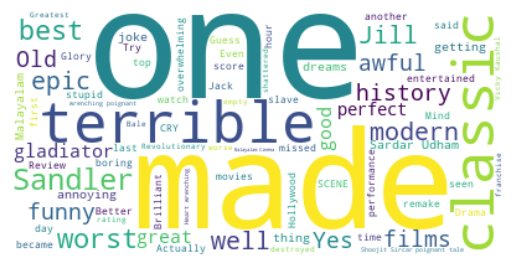

In [137]:
# Create stopword list
stopwords = set(STOPWORDS)
stopwords.update(["br", "im", "thats", "make",  "film", "movie", "people", "man", "word", "man", "thor" ]) #"im","lol","Xa","film"])
# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(all_text)
# Display the image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
#save the generated image to a file
#wordcloud.to_file("wordcloud_cb_all.png")

#### to get better results of word cloud, i remove more words like "br", "im", "thats", "one", "made", "make", "jill", "sandler", "film", "movie", "people", "man", "word", "man", "thor"

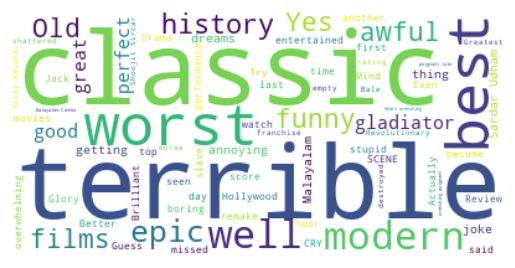

In [138]:
# Create stopword list
stopwords = set(STOPWORDS)
stopwords.update(["br", "im", "thats", "one", "made", "make", "jill", "sandler", "film", "movie", "people", "man", "word", "man", "thor" ]) #"im","lol","Xa","film"])
# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(all_text)
# Display the image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
#save the generated image to a file
#wordcloud.to_file("wordcloud_cb_all.png")

## Sentiment Identification using VADER

In [139]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to C:\Users\Dell
[nltk_data]     2022\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [140]:
sid = SentimentIntensityAnalyzer()
c = 0
for t in text:
    c+=1
    print(c, t)
    ss = sid.polarity_scores(t)
    print(ss)
    
    if(ss['compound'] >= 0.05):
        print('positive')

    elif(ss['compound'] <= -0.05):
        print('negative')
    else:
        print('neutral')
    print('\n')

1  Ladies and gentlemen, here it is, Adam Sandler's worst movie!

{'neg': 0.328, 'neu': 0.672, 'pos': 0.0, 'compound': -0.6588}
negative


2  Ladies and gentlemen, here it is, Adam Sandler's worst movie!

{'neg': 0.328, 'neu': 0.672, 'pos': 0.0, 'compound': -0.6588}
negative


3  Sandler put the "F U" in 'Failure"

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
neutral


4  Sandler put the "F U" in 'Failure"

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
neutral


5  Terrible. The trailer is the highlights.

{'neg': 0.383, 'neu': 0.617, 'pos': 0.0, 'compound': -0.4767}
negative


6  Terrible. The trailer is the highlights.

{'neg': 0.383, 'neu': 0.617, 'pos': 0.0, 'compound': -0.4767}
negative


7  Deserves to be Erased from Film History

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
neutral


8  Deserves to be Erased from Film History

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
neutral


9  Actually pretty funny

{'neg': 0.0, 'neu': 0.141, 'pos': 0.85

### Sentiment Classification using Machine Learning 

In [212]:
label = []
for r in movie['Rating']:
    r = int(r)
    if (r>5):
        label.append('1') #Positive
    elif(r<5):
        label.append('-1') #Negative
    elif(r==5):
        label.append('0') #Netural
        
movie['class-label'] = label

In [213]:
movie['class-label'].value_counts()

1     144
-1    118
0      18
Name: class-label, dtype: int64

Try-For-Fun
In this workshop, we'll work on binary classification, where only two classes are considered 'positive (1)' and
'negative (-1)'. Ignore 'neutral (0)' class. However, the code in this notebook is adopted for multiclass
classification problem. You can try all the three classes for fun.

In [143]:
movie_without_neutral = movie[movie['class-label']!='0']

In [144]:
movie_without_neutral['class-label'].value_counts()

1     144
-1    118
Name: class-label, dtype: int64

In [161]:
textFeatures2 = movie_without_neutral['Review'].copy()
textFeatures2.shape

(262,)

##### Trying  it for all three classification

In [147]:
movie_with_neutral=movie['class-label'].value_counts()

In [283]:
movie_with_neutral

1     144
-1    118
0      18
Name: class-label, dtype: int64

In [179]:
textFeatures3 = movie['Review'].copy()
textFeatures3.shape

(280,)

In [194]:
##### import nltk
nltk.download('punkt')
# Stemming using TextBlob library for stemming
from textblob import TextBlob

[nltk_data] Downloading package punkt to C:\Users\Dell
[nltk_data]     2022\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [195]:
def textblob_tokenizer(input_str):
    blob = TextBlob(input_str.lower())
    tokens = blob.words
    words = [token.stem() for token in tokens]
    return words

In [198]:
#Toy example: 
print(textblob_tokenizer('Q: studed studing!!! I miss uuuu! It&#039;s'))

['q', 'stude', 'stude', 'i', 'miss', 'uuuu', 'it', '039', 's']


In [201]:
#countvectorizer convers each review into a vector based on the word count.
countvectorizer = CountVectorizer(analyzer= 'word', stop_words= 'english', 
                                  tokenizer=textblob_tokenizer) 
#convers text into a vector based on tf-idf weighting scheme. 
tfidfvectorizer = TfidfVectorizer(analyzer= 'word', stop_words= 'english', 
                                  tokenizer=textblob_tokenizer)

##### textFeatures for without neutral classification

In [202]:
textFeatures2

0       Ladies and gentlemen, here it is, Adam Sandle...
1       Ladies and gentlemen, here it is, Adam Sandle...
2                   Sandler put the "F U" in 'Failure"\n
3                   Sandler put the "F U" in 'Failure"\n
4             Terrible. The trailer is the highlights.\n
                             ...                        
275     Easily I can say one the Greatest films ever ...
276                                        super movie\n
277                                        super movie\n
278                            Classic emotional drama\n
279                            Classic emotional drama\n
Name: Review, Length: 262, dtype: object

In [206]:
count_matrix = countvectorizer.fit_transform(textFeatures2) 
tfidf_matrix = tfidfvectorizer.fit_transform(textFeatures2)


In [204]:
print(tfidf_matrix) #print elements of the matrix.

  (0, 194)	0.24436853743335993
  (0, 308)	0.3507048676847697
  (0, 2)	0.2636564826283793
  (0, 238)	0.33666963795054344
  (0, 16)	0.45986553387744766
  (0, 127)	0.45986553387744766
  (0, 167)	0.45986553387744766
  (1, 194)	0.24436853743335993
  (1, 308)	0.3507048676847697
  (1, 2)	0.2636564826283793
  (1, 238)	0.33666963795054344
  (1, 16)	0.45986553387744766
  (1, 127)	0.45986553387744766
  (1, 167)	0.45986553387744766
  (2, 1)	0.5317962642068683
  (2, 288)	0.5317962642068683
  (2, 107)	0.5317962642068683
  (2, 238)	0.3893304510654875
  (3, 1)	0.5317962642068683
  (3, 288)	0.5317962642068683
  (3, 107)	0.5317962642068683
  (3, 238)	0.3893304510654875
  (4, 143)	0.6155904592682035
  (4, 284)	0.6155904592682035
  (4, 270)	0.4920333046816286
  :	:
  (254, 194)	0.571694831425871
  (255, 35)	0.8204663428325046
  (255, 194)	0.571694831425871
  (256, 135)	0.4313182330902095
  (256, 66)	0.4313182330902095
  (256, 134)	0.4313182330902095
  (256, 240)	0.4313182330902095
  (256, 90)	0.4313182330

Print the dimensions of the tfidf_matrix, x rows (number of reviews) and y columns (total words occur in the
entire dataset.)

In [205]:
print(count_matrix)

  (0, 167)	1
  (0, 127)	1
  (0, 16)	1
  (0, 238)	1
  (0, 2)	1
  (0, 308)	1
  (0, 194)	1
  (1, 167)	1
  (1, 127)	1
  (1, 16)	1
  (1, 238)	1
  (1, 2)	1
  (1, 308)	1
  (1, 194)	1
  (2, 238)	1
  (2, 107)	1
  (2, 288)	1
  (2, 1)	1
  (3, 238)	1
  (3, 107)	1
  (3, 288)	1
  (3, 1)	1
  (4, 270)	1
  (4, 284)	1
  (4, 143)	1
  :	:
  (254, 35)	1
  (255, 194)	1
  (255, 35)	1
  (256, 118)	1
  (256, 90)	1
  (256, 240)	1
  (256, 134)	1
  (256, 66)	1
  (256, 135)	1
  (257, 118)	1
  (257, 90)	1
  (257, 240)	1
  (257, 134)	1
  (257, 66)	1
  (257, 135)	1
  (258, 194)	1
  (258, 266)	1
  (259, 194)	1
  (259, 266)	1
  (260, 86)	1
  (260, 61)	1
  (260, 94)	1
  (261, 86)	1
  (261, 61)	1
  (261, 94)	1


In [173]:
print(tfidf_matrix.shape) 
print(count_matrix.shape)


(262, 314)
(262, 314)


As seen above  dimension of count_matrix, there are X rows (262 reviews), and Y columns (314 word features) in the transformed dataset


#### Try-For-Fun:
 

## without adopting pre-processing.

In [208]:
#countvectorizer convers each review into a vector based on the word count.
countvectorizer = CountVectorizer() 
#convers text into a vector based on tf-idf weighting scheme. 
tfidfvectorizer = TfidfVectorizer()

In [209]:
count_matrix2 = countvectorizer.fit_transform(textFeatures2) 
tfidf_matrix2 = tfidfvectorizer.fit_transform(textFeatures2)


In [210]:
print(tfidf_matrix2.shape) 
print(count_matrix2.shape)


(262, 391)
(262, 391)


As seen above dimension of count_matrix, there are X rows (262 reviews), and Y columns (391 word features) in the untransformed and unprocessed  dataset

## Build ML models 

In [292]:
features_train, features_test, labels_train, labels_test = train_test_split(
    tfidf_matrix, movie_without_neutral['class-label'], test_size=0.3,random_state=94)
print(features_train.shape, features_test.shape, labels_train.shape, labels_test.shape)

(183, 314) (79, 314) (183,) (79,)


In [234]:
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import accuracy_score


In [235]:
#SVM classifier
from sklearn.svm import SVC
print("\nEvaluation for SVM \n")
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(features_train, labels_train)
prediction = svc.predict(features_test)
acc = accuracy_score(labels_test,prediction)
print('Accuracy:', acc)
from sklearn.metrics import precision_score
prec = precision_score(labels_test,prediction, average='weighted')
print('Precision:', prec)
from sklearn.metrics import recall_score
recall = recall_score(labels_test,prediction, average='weighted')
print('Recall:', recall)
from sklearn.metrics import f1_score
f1 = f1_score(labels_test,prediction, average='weighted')
print('F-1 measure: ', f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels_test, prediction)) 
print(classification_report(labels_test, prediction))
#print(prediction


Evaluation for SVM 

Accuracy: 0.9493670886075949
Precision: 0.9533382973442541
Recall: 0.9493670886075949
F-1 measure:  0.9487126496168088

Confusion Matrix:

[[28  4]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.88      0.93        32
           1       0.92      1.00      0.96        47

    accuracy                           0.95        79
   macro avg       0.96      0.94      0.95        79
weighted avg       0.95      0.95      0.95        79



In [236]:
#Decision Tree
print("\nEvaluation for Decision Tree \n")
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(features_train, labels_train)
prediction = dtree.predict(features_test)
acc = accuracy_score(labels_test,prediction)
print('Accuracy: ', acc)
prec = precision_score(labels_test,prediction, average='weighted')
print('Preciscion: ', prec)
recall = recall_score(labels_test,prediction, average='weighted')
print('Recall: ', recall)
f1 = f1_score(labels_test,prediction, average='weighted')
print('F-1 measure: ',f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels_test, prediction)) 
print(classification_report(labels_test, prediction))


Evaluation for Decision Tree 

Accuracy:  0.9240506329113924
Preciscion:  0.9326486744685933
Recall:  0.9240506329113924
F-1 measure:  0.9224006983849846

Confusion Matrix:

[[26  6]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.81      0.90        32
           1       0.89      1.00      0.94        47

    accuracy                           0.92        79
   macro avg       0.94      0.91      0.92        79
weighted avg       0.93      0.92      0.92        79



### Try-It-Yourself:
Produce wordclouds of 'positive' and 'negative' reviews independently and reflect on the two wordclouds.
In the above models, we used tf-idf scheme, use BoW scheme (count_matrix) in the similar way to build
the two new models. Include these in your evaluation.

##### Produce wordclouds of 'positive' and 'negative' reviews independently and reflect on the two wordclouds.

# wordcloud of positive reviews 

In [260]:
positive_reviewcloud = movie[movie['class-label'] =='1']

In [261]:
positive_reviewcloud.head()

,Review,Rating,class-label
8,Actually pretty funny\n,6,1
9,Actually pretty funny\n,6,1
12,One of my favourite Sandler movies dont get t...,8,1
13,One of my favourite Sandler movies dont get t...,8,1
36,Over the top funny\n,8,1


In [262]:
positive_reviewcloud =positive_reviewcloud['Review'].copy()

In [263]:
positive_reviewcloud.shape

(144,)

In [264]:
#Preparing text for Wordcloud
text = []
for t in positive_reviewcloud:
    text.append(t)

all_textpositive = ', '.join(t for t in text)
#print(all_text)
print(len(all_textpositive))

6296


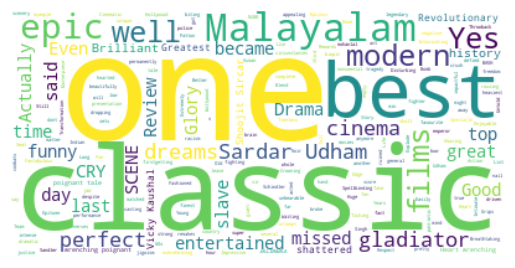

In [268]:
# Create stopword list
stopwords = set(STOPWORDS)
stopwords.update(["br", "im", "thats", "make", "made",  "film", "movie", "people", "man", "word", "man", "thor" ]) #"im","lol","Xa","film"])
# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(all_textp)
# Display the image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
#save the generated image to a file
#wordcloud.to_file("wordcloud_cb_all.png")

##  wordcloud of negative reviews 

In [269]:
negative_reviewcloud = movie[movie['class-label'] =='-1']

In [270]:
negative_reviewcloud.shape

(118, 3)

In [271]:
negative_reviewcloud =negative_reviewcloud['Review'].copy()

In [272]:
negative_reviewcloud.shape

(118,)

In [273]:
#Preparing text for Wordcloud
text = []
for t in negative_reviewcloud:
    text.append(t)

all_textnegative = ', '.join(t for t in text)
#print(all_text)
print(len(all_textnegative ))

4020


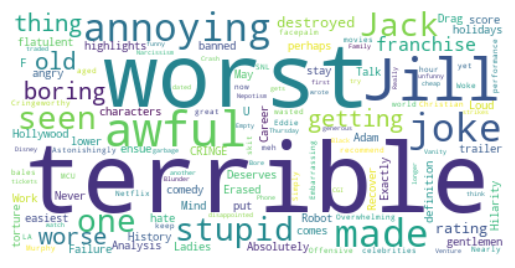

In [277]:
# Create stopword list
stopwords = set(STOPWORDS)
stopwords.update(["br", "im", "thats", "make", "sandler",  "film", "movie", "people", "man", "word", "man", "thor" ]) #"im","lol","Xa","film"])
# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(all_textnegative)
# Display the image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
#save the generated image to a file
#wordcloud.to_file("wordcloud_cb_all.png")

## NEW MODELS USING COUNT-MATRIX SCHEME

In [304]:
features2_train, features2_test, labels2_train, labels2_test = train_test_split(
    count_matrix, movie_without_neutral['class-label'], test_size=0.3,random_state=94)
print(features2_train.shape, features2_test.shape, labels2_t rain.shape, labels2_test.shape)

(183, 314) (79, 314) (183,) (79,)


In [307]:
#SVM classifier
from sklearn.svm import SVC
print("\nEvaluation for SVM \n")
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(features2_train, labels2_train)
prediction = svc.predict(features2_test)
acc = accuracy_score(labels2_test,prediction)
print('Accuracy:', acc)
from sklearn.metrics import precision_score
prec = precision_score(labels2_test,prediction, average='weighted')
print('Precision:', prec)
from sklearn.metrics import recall_score
recall = recall_score(labels2_test,prediction, average='weighted')
print('Recall:', recall)
from sklearn.metrics import f1_score
f1 = f1_score(labels2_test,prediction, average='weighted')
print('F-1 measure: ', f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels2_test, prediction)) 
print(classification_report(labels2_test, prediction))
#print(prediction


Evaluation for SVM 

Accuracy: 0.8354430379746836
Precision: 0.8398076606937366
Recall: 0.8354430379746836
F-1 measure:  0.8364146716687808

Confusion Matrix:

[[27  5]
 [ 8 39]]
              precision    recall  f1-score   support

          -1       0.77      0.84      0.81        32
           1       0.89      0.83      0.86        47

    accuracy                           0.84        79
   macro avg       0.83      0.84      0.83        79
weighted avg       0.84      0.84      0.84        79



In [306]:
#Decision Tree
print("\nEvaluation for Decision Tree \n")
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(features2_train, labels2_train)
prediction = dtree.predict(features2_test)
acc = accuracy_score(labels2_test,prediction)
print('Accuracy: ', acc)
prec = precision_score(labels2_test,prediction, average='weighted')
print('Preciscion: ', prec)
recall = recall_score(labels2_test,prediction, average='weighted')
print('Recall: ', recall)
f1 = f1_score(labels2_test,prediction, average='weighted')
print('F-1 measure: ',f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels2_test, prediction)) 
print(classification_report(labels2_test, prediction))


Evaluation for Decision Tree 

Accuracy:  0.9240506329113924
Preciscion:  0.9326486744685933
Recall:  0.9240506329113924
F-1 measure:  0.9224006983849846

Confusion Matrix:

[[26  6]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.81      0.90        32
           1       0.89      1.00      0.94        47

    accuracy                           0.92        79
   macro avg       0.94      0.91      0.92        79
weighted avg       0.93      0.92      0.92        79



## NEW MODELS WITHOUT PRE-PROCESSING USING TF-IDF SCHEME

In [296]:
features1_train, features1_test, labels1_train, labels1_test = train_test_split(
    tfidf_matrix2, movie_without_neutral['class-label'], test_size=0.3,random_state=94)
print(features1_train.shape, features1_test.shape, labels1_train.shape, labels_test.shape)

(183, 391) (79, 391) (183,) (79,)


In [299]:
#SVM classifier
from sklearn.svm import SVC
print("\nEvaluation for SVM \n")
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(features1_train, labels1_train)
prediction = svc.predict(features1_test)
acc = accuracy_score(labels_test,prediction)
print('Accuracy:', acc)
from sklearn.metrics import precision_score
prec = precision_score(labels1_test,prediction, average='weighted')
print('Precision:', prec)
from sklearn.metrics import recall_score
recall = recall_score(labels1_test,prediction, average='weighted')
print('Recall:', recall)
from sklearn.metrics import f1_score
f1 = f1_score(labels1_test,prediction, average='weighted')
print('F-1 measure: ', f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels1_test, prediction)) 
print(classification_report(labels1_test, prediction))
#print(prediction


Evaluation for SVM 

Accuracy: 0.9240506329113924
Precision: 0.9244295186429002
Recall: 0.9240506329113924
F-1 measure:  0.923616782360147

Confusion Matrix:

[[28  4]
 [ 2 45]]
              precision    recall  f1-score   support

          -1       0.93      0.88      0.90        32
           1       0.92      0.96      0.94        47

    accuracy                           0.92        79
   macro avg       0.93      0.92      0.92        79
weighted avg       0.92      0.92      0.92        79



In [301]:
#Decision Tree
print("\nEvaluation for Decision Tree \n")
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(features1_train, labels1_train)
prediction = dtree.predict(features1_test)
acc = accuracy_score(labels1_test,prediction)
print('Accuracy: ', acc)
prec = precision_score(labels1_test,prediction, average='weighted')
print('Preciscion: ', prec)
recall = recall_score(labels1_test,prediction, average='weighted')
print('Recall: ', recall)
f1 = f1_score(labels1_test,prediction, average='weighted')
print('F-1 measure: ',f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels1_test, prediction)) 
print(classification_report(labels1_test, prediction))


Evaluation for Decision Tree 

Accuracy:  0.8987341772151899
Preciscion:  0.9010743537921498
Recall:  0.8987341772151899
F-1 measure:  0.8974252992336174

Confusion Matrix:

[[26  6]
 [ 2 45]]
              precision    recall  f1-score   support

          -1       0.93      0.81      0.87        32
           1       0.88      0.96      0.92        47

    accuracy                           0.90        79
   macro avg       0.91      0.88      0.89        79
weighted avg       0.90      0.90      0.90        79



## NEW MODELS WITHOUT PRE-PROCESSING USING COUNT-MATRIX SCHEME

In [314]:
features3_train, features3_test, labels3_train, labels3_test = train_test_split(
    count_matrix2, movie_without_neutral['class-label'], test_size=0.3,random_state=94)
print(features3_train.shape, features3_test.shape, labels3_train.shape, labels3_test.shape)

(183, 391) (79, 391) (183,) (79,)


In [312]:
#SVM classifier
from sklearn.svm import SVC
print("\nEvaluation for SVM \n")
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(features3_train, labels3_train)
prediction = svc.predict(features3_test)
acc = accuracy_score(labels3_test,prediction)
print('Accuracy:', acc)
from sklearn.metrics import precision_score
prec = precision_score(labels3_test,prediction, average='weighted')
print('Precision:', prec)
from sklearn.metrics import recall_score
recall = recall_score(labels3_test,prediction, average='weighted')
print('Recall:', recall)
from sklearn.metrics import f1_score
f1 = f1_score(labels3_test,prediction, average='weighted')
print('F-1 measure: ', f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels3_test, prediction)) 
print(classification_report(labels3_test, prediction))
#print(prediction


Evaluation for SVM 

Accuracy: 0.7088607594936709
Precision: 0.714335032056551
Recall: 0.7088607594936709
F-1 measure:  0.7105798037216893

Confusion Matrix:

[[22 10]
 [13 34]]
              precision    recall  f1-score   support

          -1       0.63      0.69      0.66        32
           1       0.77      0.72      0.75        47

    accuracy                           0.71        79
   macro avg       0.70      0.71      0.70        79
weighted avg       0.71      0.71      0.71        79



In [313]:
#Decision Tree
print("\nEvaluation for Decision Tree \n")
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(features3_train, labels3_train)
prediction = dtree.predict(features3_test)
acc = accuracy_score(labels3_test,prediction)
print('Accuracy: ', acc)
prec = precision_score(labels3_test,prediction, average='weighted')
print('Preciscion: ', prec)
recall = recall_score(labels3_test,prediction, average='weighted')
print('Recall: ', recall)
f1 = f1_score(labels3_test,prediction, average='weighted')
print('F-1 measure: ',f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels3_test, prediction)) 
print(classification_report(labels3_test, prediction))


Evaluation for Decision Tree 

Accuracy:  0.9240506329113924
Preciscion:  0.9326486744685933
Recall:  0.9240506329113924
F-1 measure:  0.9224006983849846

Confusion Matrix:

[[26  6]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.81      0.90        32
           1       0.89      1.00      0.94        47

    accuracy                           0.92        79
   macro avg       0.94      0.91      0.92        79
weighted avg       0.93      0.92      0.92        79



In [233]:
features_train, features_test, labels_train, labels_test = train_test_split(
    tfidf_matrix, movie_without_neutral['class-label'], test_size=0.3,random_state=94)
print(features_train.shape, features_test.shape, labels_train.shape, labels_test.shape)

(183, 314) (79, 314) (183,) (79,)


In [234]:
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import accuracy_score


In [235]:
#SVM classifier
from sklearn.svm import SVC
print("\nEvaluation for SVM \n")
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(features_train, labels_train)
prediction = svc.predict(features_test)
acc = accuracy_score(labels_test,prediction)
print('Accuracy:', acc)
from sklearn.metrics import precision_score
prec = precision_score(labels_test,prediction, average='weighted')
print('Precision:', prec)
from sklearn.metrics import recall_score
recall = recall_score(labels_test,prediction, average='weighted')
print('Recall:', recall)
from sklearn.metrics import f1_score
f1 = f1_score(labels_test,prediction, average='weighted')
print('F-1 measure: ', f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels_test, prediction)) 
print(classification_report(labels_test, prediction))
#print(prediction


Evaluation for SVM 

Accuracy: 0.9493670886075949
Precision: 0.9533382973442541
Recall: 0.9493670886075949
F-1 measure:  0.9487126496168088

Confusion Matrix:

[[28  4]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.88      0.93        32
           1       0.92      1.00      0.96        47

    accuracy                           0.95        79
   macro avg       0.96      0.94      0.95        79
weighted avg       0.95      0.95      0.95        79



In [236]:
#Decision Tree
print("\nEvaluation for Decision Tree \n")
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(features_train, labels_train)
prediction = dtree.predict(features_test)
acc = accuracy_score(labels_test,prediction)
print('Accuracy: ', acc)
prec = precision_score(labels_test,prediction, average='weighted')
print('Preciscion: ', prec)
recall = recall_score(labels_test,prediction, average='weighted')
print('Recall: ', recall)
f1 = f1_score(labels_test,prediction, average='weighted')
print('F-1 measure: ',f1)
print('\nConfusion Matrix:\n')
print(confusion_matrix(labels_test, prediction)) 
print(classification_report(labels_test, prediction))


Evaluation for Decision Tree 

Accuracy:  0.9240506329113924
Preciscion:  0.9326486744685933
Recall:  0.9240506329113924
F-1 measure:  0.9224006983849846

Confusion Matrix:

[[26  6]
 [ 0 47]]
              precision    recall  f1-score   support

          -1       1.00      0.81      0.90        32
           1       0.89      1.00      0.94        47

    accuracy                           0.92        79
   macro avg       0.94      0.91      0.92        79
weighted avg       0.93      0.92      0.92        79

